In [1]:
from pathlib import Path
from ase.io import read, write
from ase.build import bulk

# Si.cif holds the conventional (8-atom) cubic cell; pull just the lattice
# constant from it and build the 2-atom primitive diamond cell QE expects.
conventional = read("Si.cif")
a = conventional.cell.cellpar()[0]  # angstrom
atoms = bulk("Si", "diamond", a=a)

In [ ]:
pseudo_dir = str(Path(".").resolve())
pseudopotentials = {"Si": "Si.pbe-n-kjpaw_psl.1.0.0.UPF"}

input_data = {
    "control": {
        "calculation": "bands",
        "prefix": "basic",
        "verbosity": "low",
        "pseudo_dir": pseudo_dir,
        "outdir": ".",
        "tprnfor": True,
        "tstress": True,
    },
    "system": {
        "nat": 2,
        "ntyp": 1,
        "ecutwfc": 50.0,
        "ecutrho": 200.0,
        "input_dft": "pbe",
        "occupations": "smearing",
        "smearing": "mv",
        "degauss": 0.005,
        "nbnd": 10,
    },
    "electrons": {
        "conv_thr": 1e-08,
        "mixing_beta": 0.7,
    },
}

In [3]:
# Special k-point path for the cell's Bravais lattice (FCC -> GXWKGLUWLK,UX for Si)
path = atoms.cell.bandpath(atoms.cell.get_bravais_lattice().special_path, npoints=0)
labels = path.path.replace(",", "")
n_per_segment = 30

write("basic_bands.in", atoms, format="espresso-in", input_data=input_data,
      pseudopotentials=pseudopotentials, kpts=path, crystal_coordinates=True)

# ASE's crystal_b writer hardcodes each row's point count to 0 and skips labels;
# patch in QE's per-segment point count + "!label" convention by hand.
lines = Path("basic_bands.in").read_text().splitlines(keepends=True)
start = next(i for i, l in enumerate(lines) if l.startswith("K_POINTS")) + 2
for i, label in enumerate(labels):
    n = n_per_segment if i < len(labels) - 1 else 0
    kx, ky, kz = path.kpts[i]
    lines[start + i] = f" {kx:.6f} {ky:.6f} {kz:.6f} {n} !{label}\n"
Path("basic_bands.in").write_text("".join(lines))

1361

Before running the next cell, run a scf calculation and then a bands calculation using pw.x, and then run a calculation using bands.x

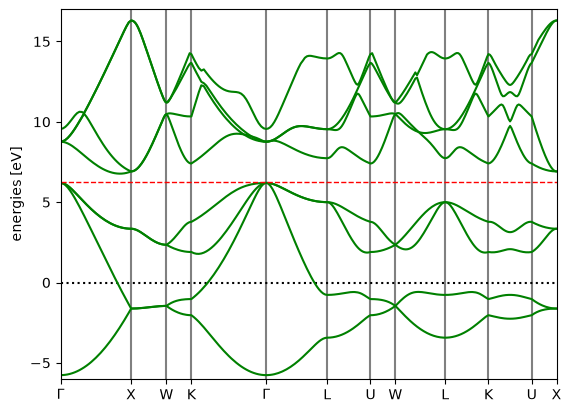

In [13]:
import numpy as np
from ase.dft.kpoints import BandPath
from ase.spectrum.band_structure import BandStructure

# Parse bands.x's filband output: header gives nbnd/nks, then each k-point is
# a "kx ky kz" line followed by nbnd eigenvalues (eV).
with open("siliconbands.dat") as f:
    header = f.readline()
    tokens = iter(f.read().split())
nbnd = int(header.split("nbnd=")[1].split(",")[0])
nks = int(header.split("nks=")[1].split("/")[0])

energies = np.empty((nks, nbnd))
for ik in range(nks):
    next(tokens), next(tokens), next(tokens)  # k-point coords, unused
    energies[ik] = [float(next(tokens)) for _ in range(nbnd)]

# Rebuild the full (331-point) k-path bands.x sampled, from the same vertices
# and points-per-segment used to write the K_POINTS card above.
vertices = path.kpts
full_kpts = np.concatenate(
    [np.linspace(vertices[i], vertices[i + 1], n_per_segment, endpoint=False)
     for i in range(len(vertices) - 1)]
    + [vertices[-1:]]
)
full_path = BandPath(atoms.cell, full_kpts, path=path.path, special_points=path.special_points)

bs = BandStructure(full_path, energies[np.newaxis])  # single spin channel
axes = bs.plot(emin=-6, emax=17)
axes.axhline(6.2543, color="r", ls="--", lw=1)  # Fermi energy from bands.x output